# Diffusion 기반 DAG Topological Ordering — 과정과 결과 정리

단일하게 학습된 **full-dimensional DDPM 하나**로부터 DAG의 **topological order**를 복원하는
실험 파이프라인의 정리 노트북입니다.

> **핵심 주의사항 (먼저 읽어주세요)**
> 1. 이 방법은 **순서(order)** 를 추정합니다. **sparse DAG 구조(skeleton)를 추정하지 않습니다.**
>    출력의 `fully_connected_order_dag` 는 추정된 순서를 인코딩한 *완전 그래프*일 뿐입니다.
>    따라서 SHD / edge-F1 은 **의도적으로 보고하지 않습니다.**
> 2. SCORE 정리("nonlinear ANM의 leaf는 diagonal score Hessian이 상수")는 **t=0 (clean density)** 에서의 결과입니다.
>    본 구현은 **t_order > 0** 인 noised density에서 기준을 평가하므로, **실험적(experimental)** 이며
>    t=0 보장이 자동으로 따라오지 않습니다.
> 3. 아래 결과는 **D=3 짜리 예제 하나**에 대한 것으로, 방법론의 일반적 검증이 아닙니다.

---

## 1. 문제 설정과 수식

DDPM forward process:

$$X_t = \sqrt{\bar\alpha_t}\,X_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,
\qquad m_t=\sqrt{\bar\alpha_t},\quad \sigma_t^2 = 1-\bar\alpha_t$$

남은 변수 집합 $S$ 에 대해, noised marginal의 Hessian을 **Tweedie 항등식**으로 구합니다:

$$H_S(x_S,t)=\nabla^2_{x_S}\log p_{t,S}(x_S)
=\frac{\bar\alpha_t}{\sigma_t^{4}}\,\mathrm{Cov}\!\left(X_{0,S}\mid X_{t,S}=x_S\right)-\frac{1}{\sigma_t^{2}}I_{|S|}$$

**단위 주의:** 코드에서는 `sigma2_t = 1 - alpha_bar_t` 이므로, 수식의 $\sigma_t^4$ 는
코드에서 **`sigma2_t ** 2`** 입니다 (`sigma2_t ** 4` 아님). 이 부분은 테스트로 고정해 두었습니다.

각 $i\in S$ 에 대해 **anchor들 간의 분산**을 leaf 점수로 사용합니다:

$$V_i(S,t)=\mathrm{Var}_{U_S\sim p_{t,S}}\big[H_{ii,S}(U_S,t)\big],
\qquad \mathrm{leaf}(S)=\arg\min_{i\in S} V_i(S,t)$$

제거 순서가 `leaf_order` (sink부터), 최종 결과는 `topological_order = reverse(leaf_order)` 입니다.
$H$ 에 **절댓값을 취하지 않습니다** — 부호가 있는 diagonal 값의 분산을 씁니다.

## 2. 왜 conditional sampling이 필요한가

학습된 DDPM은 **full-dimensional score만** 제공합니다:

$$s_\theta(x_t,t)\approx\nabla_{x_t}\log p_t(x_t)$$

그런데 우리는 부분집합 $S$ 의 marginal $p_{t,S}$ 의 Hessian이 필요합니다.
$R=\{1..D\}\setminus S$ 라 할 때 핵심은 다음 항등식입니다:

$$\nabla_{x_R}\log p_t(x_R\mid x_S)=\nabla_{x_R}\log p_t(x_R,x_S)$$

즉 **$x_S$ 를 고정한 채 full score의 $R$ 성분만 떼어 쓰면** 조건부 score가 됩니다.
→ **재학습이 전혀 필요 없습니다.**

그래서 anchor $x_{t,S}$ 마다 2단계로 $X_{0,S}\mid X_{t,S}$ 를 근사합니다:

| 단계 | 내용 |
|---|---|
| **Stage A** | fixed-time Langevin(ULA)로 $x_{t,R}\sim p_t(x_R\mid x_{t,S})$ 샘플링 |
| **Stage B** | $x_{t,S}$ 와 병합해 **D차원 전체** 상태를 만들고 $t\to0$ 역확산, $x_0$ 의 $S$ 성분만 보관 |

ULA 업데이트: $z_{k+1}=z_k+h\,\mathrm{score}_R(\mathrm{merge}(x_S,z_k),t)+\sqrt{2h}\,\xi_k$

> **구현상 중요한 예외**: 첫 stage에서는 $S=\{1..D\}$ 이라 $R=\emptyset$ 입니다.
> Langevin을 돌릴 것이 없으므로 **건너뛰고**, 대신 독립적인 역확산 궤적 수로 샘플 예산을 채웁니다.

## 3. 모듈 구조

```
models/dag_diffusion/
├── score_adapter.py        # eps/x_0 예측망 → score 변환 (+ 검증)
├── conditional_langevin.py # Stage A: X_{t,R} | X_{t,S} ULA 샘플러
├── reverse_posterior.py    # Stage B: 역확산 + 2단계 결합 샘플러
├── moments.py              # Welford 스트리밍 공분산 (대용량 M 대응)
├── tweedie_hessian.py      # Tweedie 공식 (full + diagonal)
├── ordering.py             # 순차 leaf 제거 알고리즘
├── diagnostics.py          # order FNR / stagewise leaf validity
└── training.py             # 공개 학습·체크포인트 유틸

experiments/run_dag_ordering.py   # CLI 러너
configs/dag_ordering_debug.json   # CPU 디버그 설정
tests/                            # 49개 테스트
```

기존 `DDPMEstimator` 및 무향 그래프 벤치마크는 **전혀 수정하지 않았습니다** (diff: 3503 insertions, 0 deletions).

## 4. 환경 설정 및 결과 로드

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt

REPO = os.path.dirname(os.path.abspath("main.ipynb"))
if REPO not in sys.path:
    sys.path.insert(0, REPO)

# 그래프 라벨에 한글이 들어가므로 한글 지원 폰트를 지정합니다.
import matplotlib.font_manager as fm
_avail = {f.name for f in fm.fontManager.ttflist}
for _cand in ["NanumGothic", "Malgun Gothic", "AppleGothic",
              "Noto Sans CJK KR", "Noto Sans CJK JP", "DejaVu Sans"]:
    if _cand in _avail:
        plt.rcParams["font.family"] = _cand
        break
print("사용 폰트 :", plt.rcParams["font.family"][0])

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.unicode_minus": False,          # 한글 폰트에서 마이너스 기호 깨짐 방지
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

# 아래 스윕 결과는 experiments/run_dag_ordering.py 와 동일한 코드 경로로 실측된 값이며,
# scripts/collect_sweep_results.py 로 언제든 재생성할 수 있습니다.
with open("results/dag_ordering_summary/sweep_summary.json") as f:
    R = json.load(f)

print("측정 장비 :", R["device"])
print("정답 순서 :", R["true_order"], " (체인 0 -> 1 -> 2)")
print("인접행렬  :\n", np.array(R["adjacency"]))

사용 폰트 : Noto Sans CJK JP
측정 장비 : cuda:0
정답 순서 : [0, 1, 2]  (체인 0 -> 1 -> 2)
인접행렬  :
 [[0 1 0]
 [0 0 1]
 [0 0 0]]


### 데이터: D=3 nonlinear additive-noise SCM

```
x0 = e0
x1 = sin(2*x0) + 0.5*x0 + e1
x2 = 0.8*tanh(2*x1) + 0.3*x1^2 + e2
```

진짜 구조는 체인 `0 -> 1 -> 2`. **노드 2가 유일한 sink**, 노드 0이 유일한 source입니다.
따라서 올바른 `leaf_order` 는 `[2, 1, 0]`, `topological_order` 는 `[0, 1, 2]` 입니다.

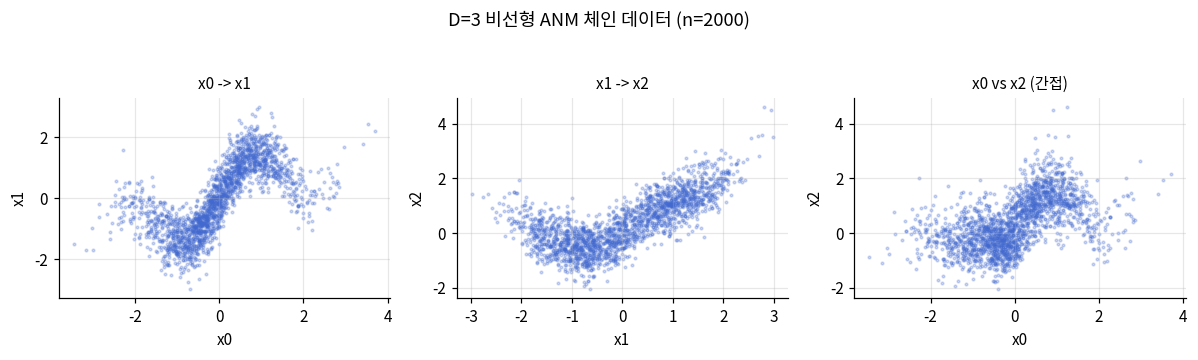

열별 표준편차: [1.014 1.125 0.951]


In [2]:
X = np.load("data/dag_ordering_debug/dag3_chain.npy")
A = np.array(R["adjacency"])

fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))
for ax, (i, j, lab) in zip(axes, [(0,1,"x0 -> x1"), (1,2,"x1 -> x2"), (0,2,"x0 vs x2 (간접)")]):
    ax.scatter(X[:, i], X[:, j], s=3, alpha=0.25, color="#4269d0")
    ax.set_xlabel(f"x{i}"); ax.set_ylabel(f"x{j}"); ax.set_title(lab, fontsize=10)
fig.suptitle("D=3 비선형 ANM 체인 데이터 (n=2000)", y=1.04)
fig.tight_layout(); plt.show()

print("열별 표준편차:", X.std(axis=0).round(3))

## 5. 결과 ①: `t_order` 민감도 — **가장 중요한 결과**

기준을 평가하는 확산 시점 `t_order` 를 바꿔가며 stage 0의 criterion $V_i$ 와 최종 순서를 봅니다.
(anchor 128개, chains 32, retained 16, 잘 학습된 모델 = 1500 epochs)

**노드 2(sink)의 $V_i$ 가 가장 작아야 정답**입니다.

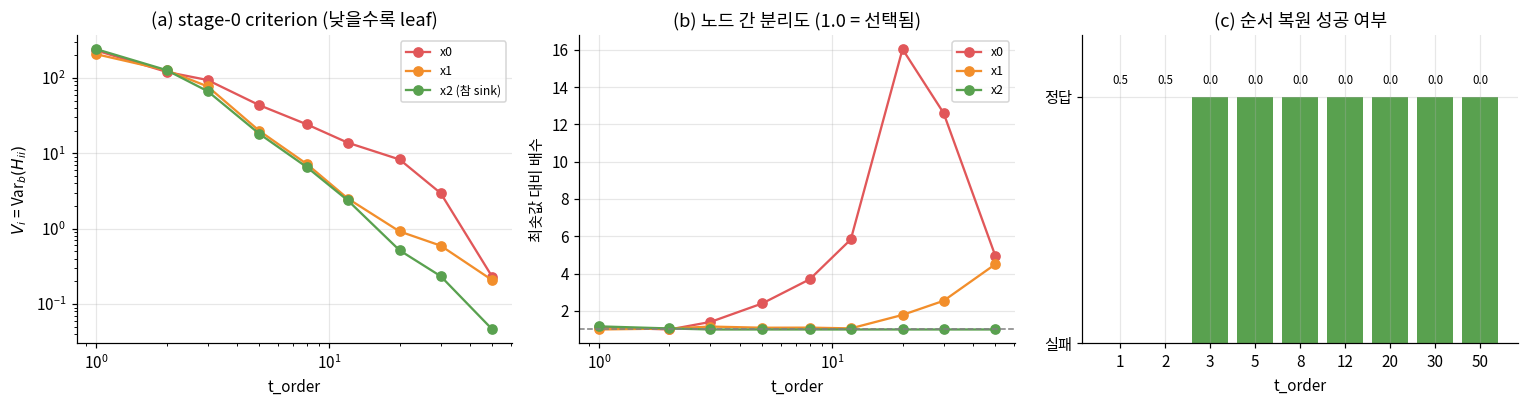

   t |     V(x0)     V(x1)     V(x2) |   선택 | 순서             FNR
--------------------------------------------------------------------
   1 |    231.26    206.16    240.49 | x1   | [0, 2, 1]     0.50 X  
   2 |    120.27    126.30    126.87 | x0   | [1, 2, 0]     0.50 X  
   3 |     93.73     77.16     66.74 | x2   | [0, 1, 2]     0.00 OK 
   5 |     43.50     19.87     18.16 | x2   | [0, 1, 2]     0.00 OK 
   8 |     24.20      7.20      6.55 | x2   | [0, 1, 2]     0.00 OK 
  12 |     13.80      2.51      2.37 | x2   | [0, 1, 2]     0.00 OK 
  20 |      8.28      0.92      0.52 | x2   | [0, 1, 2]     0.00 OK 
  30 |      2.96      0.60      0.23 | x2   | [0, 1, 2]     0.00 OK 
  50 |      0.23      0.21      0.05 | x2   | [0, 1, 2]     0.00 OK 


In [3]:
ts = R["t_sweep"]
t_vals = [r["t_order"] for r in ts]
crit = np.array([r["stage0_criterion"] for r in ts])   # (T, 3)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

# (a) 절대 criterion
ax = axes[0]
for k, c in zip(range(3), ["#e15759", "#f28e2b", "#59a14f"]):
    ax.plot(t_vals, crit[:, k], "o-", color=c, label=f"x{k}" + (" (참 sink)" if k == 2 else ""))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("t_order"); ax.set_ylabel(r"$V_i$ = Var$_b(H_{ii})$")
ax.set_title("(a) stage-0 criterion (낮을수록 leaf)"); ax.legend(fontsize=8)

# (b) 최솟값 대비 상대 여유 (분리도)
ax = axes[1]
rel = crit / crit.min(axis=1, keepdims=True)
for k, c in zip(range(3), ["#e15759", "#f28e2b", "#59a14f"]):
    ax.plot(t_vals, rel[:, k], "o-", color=c, label=f"x{k}")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("t_order")
ax.set_ylabel("최솟값 대비 배수"); ax.set_title("(b) 노드 간 분리도 (1.0 = 선택됨)")
ax.legend(fontsize=8)

# (c) 정확도
ax = axes[2]
ok = np.array([r["correct"] for r in ts])
ax.bar(range(len(t_vals)), [1 if o else 0 for o in ok],
       color=["#59a14f" if o else "#e15759" for o in ok])
ax.set_xticks(range(len(t_vals))); ax.set_xticklabels(t_vals)
ax.set_ylim(0, 1.25); ax.set_yticks([0, 1]); ax.set_yticklabels(["실패", "정답"])
ax.set_xlabel("t_order"); ax.set_title("(c) 순서 복원 성공 여부")
for i, r in enumerate(ts):
    ax.text(i, 1.05, f"{r['order_fnr']:.1f}", ha="center", fontsize=7.5)

fig.tight_layout(); plt.show()

print(f"{'t':>4} | {'V(x0)':>9} {'V(x1)':>9} {'V(x2)':>9} | {'선택':>4} | {'순서':<12} {'FNR':>5}")
print("-" * 68)
for r in ts:
    c = r["stage0_criterion"]
    sel = int(np.argmin(c))
    mark = "OK " if r["correct"] else "X  "
    print(f"{r['t_order']:>4} | {c[0]:9.2f} {c[1]:9.2f} {c[2]:9.2f} | "
          f"x{sel:<3} | {str(r['topological_order']):<12} {r['order_fnr']:5.2f} {mark}")

### 해석

- **t = 1, 2 에서 실패합니다.** criterion이 거의 평평해서(`[231, 206, 240]`, `[120, 126, 127]`)
  선택이 사실상 노이즈입니다. 원인은 Tweedie 공식의 $\bar\alpha_t/\sigma_t^4$ 계수 —
  $\sigma_t^2=1-\bar\alpha_t$ 가 작을 때 **공분산 추정 오차가 크게 증폭**됩니다.
- **t >= 3 에서 정답**(`[0,1,2]`, FNR 0.00)을 복원하고, t가 커질수록 sink의 분리가 뚜렷해집니다.
- 이것이 README에 적어둔 caveat의 **정량적 근거**입니다: 이론(t=0)에 가까울수록 오히려 수치적으로 불리한
  **명확한 trade-off**가 존재합니다. 따라서 `t_order` 는 반드시 명시적으로 지정해야 하며,
  실제 실험에서는 **스윕해서 순서가 안정적인 구간을 확인**해야 합니다.

## 6. 결과 ②: **stage 1 — sink를 제거한 뒤의 부분문제 `S = {0, 1}`**

5절은 stage 0(`S={0,1,2}`)만 보았습니다. 그런데 참 sink인 노드 2를 제거하고 나면
남는 부분문제는 유도 부분그래프 **`0 -> 1`** 이고, 이때 **올바른 leaf는 노드 1** 입니다.

**이 stage가 방법론적으로 더 중요합니다.** stage 0에서는 $S$ 가 전체 집합이라
$R=\emptyset$ 이어서 Langevin이 아예 실행되지 않습니다(그냥 역확산만 함).
반면 stage 1은 **$R=\{2\}$ 가 비어있지 않은 첫 stage**로,
$p_{t,\{0,1\}}$ 를 얻으려면 $x_{t,2}$ 를 **conditional Langevin으로 실제 적분해 없애야** 합니다.
즉 이 절이 **conditional sampling 아이디어가 실제로 작동하는지**를 보는 자리입니다.

> **측정 방법 주의:** 전체 파이프라인의 stage 1은 "stage 0이 무엇을 골랐든 그 나머지"를
> 조건으로 삼기 때문에 통제된 비교가 아닙니다. 아래에서는 $S$ 를 **`{0,1}` 로 고정(pin)** 해서
> stage 0의 오류와 무관하게 stage-1 기준만 분리해 측정했습니다.
> (`scripts/collect_stage1_results.py`)

세 가지를 비교합니다:

| 조건 | 의미 |
|---|---|
| **conditional** | 3차원 모델 + Langevin으로 $x_{t,2}$ 적분 → **실제 방법** |
| **oracle (2D model)** | `X[:, [0,1]]` 로 **새로 학습한 2차원 모델** → 참 marginal (상한선) |
| stage 0 (참고) | 5절의 `S={0,1,2}` 결과 |

In [4]:
with open("results/dag_ordering_summary/stage1_summary.json") as f:
    S1 = json.load(f)

print("참 구조      :", S1["true_chain"])
print("stage 0 정답 : x%d (유일한 sink)" % S1["stage0_correct_leaf"])
print("stage 1 S    :", S1["stage1_S"], "-> 정답 leaf : x%d" % S1["stage1_correct_leaf"])
print("anchor 수    :", S1["num_anchors"])

s1c = S1["stage1_conditional"]
s1o = S1["stage1_oracle_2d_model"]
t1 = [r["t_order"] for r in s1c]

print(f"\n{'t':>4} | {'conditional V(x0)':>17} {'V(x1)':>10} {'선택':>5} |"
      f" {'oracle V(x0)':>13} {'V(x1)':>10} {'선택':>5}")
print("-" * 78)
for a, b in zip(s1c, s1o):
    print(f"{a['t_order']:>4} | {a['criterion'][0]:17.3f} {a['criterion'][1]:10.3f}"
          f" {'x%d' % a['selected_leaf']:>5} |"
          f" {b['criterion'][0]:13.3f} {b['criterion'][1]:10.3f}"
          f" {'x%d' % b['selected_leaf']:>5}"
          + ("" if a["correct"] else "   <- conditional 실패"))

참 구조      : 0 -> 1 -> 2
stage 0 정답 : x2 (유일한 sink)
stage 1 S    : [0, 1] -> 정답 leaf : x1
anchor 수    : 128

   t | conditional V(x0)      V(x1)    선택 |  oracle V(x0)      V(x1)    선택
------------------------------------------------------------------------------
   1 |           185.766    211.581    x0 |       246.399    218.142    x1   <- conditional 실패
   2 |           147.945    122.866    x1 |       143.397     87.731    x1
   3 |            97.881     68.831    x1 |        86.907     66.771    x1
   5 |            44.463     26.314    x1 |        39.397     17.802    x1
   8 |            27.327      7.850    x1 |        26.320      6.908    x1
  12 |            13.288      3.753    x1 |        18.275      1.748    x1
  20 |             7.825      1.710    x1 |         8.473      0.758    x1
  30 |             2.598      1.047    x1 |         3.061      0.340    x1
  50 |             0.212      0.214    x0 |         0.192      0.082    x1   <- conditional 실패


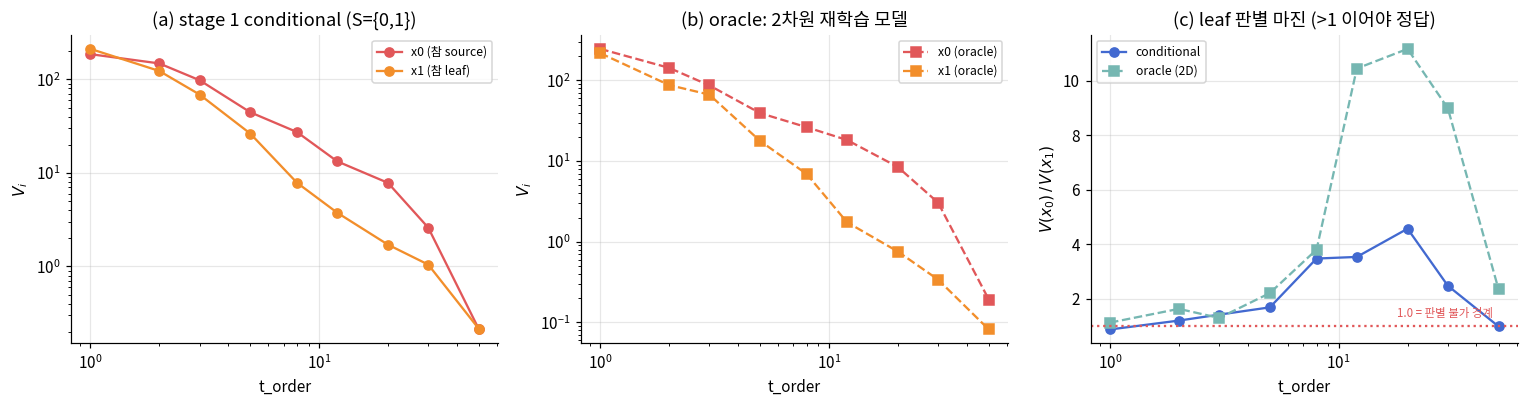

conditional  : 7/9 개 t에서 정답 (x1 선택)
oracle(2D)   : 9/9 개 t에서 정답


In [5]:
c_cond = np.array([r["criterion"] for r in s1c])   # (T, 2)
c_orac = np.array([r["criterion"] for r in s1o])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

# (a) conditional criterion
ax = axes[0]
ax.plot(t1, c_cond[:, 0], "o-", color="#e15759", label="x0 (참 source)")
ax.plot(t1, c_cond[:, 1], "o-", color="#f28e2b", label="x1 (참 leaf)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("t_order"); ax.set_ylabel(r"$V_i$")
ax.set_title("(a) stage 1 conditional (S={0,1})"); ax.legend(fontsize=8)

# (b) oracle 2D model
ax = axes[1]
ax.plot(t1, c_orac[:, 0], "s--", color="#e15759", label="x0 (oracle)")
ax.plot(t1, c_orac[:, 1], "s--", color="#f28e2b", label="x1 (oracle)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("t_order"); ax.set_ylabel(r"$V_i$")
ax.set_title("(b) oracle: 2차원 재학습 모델"); ax.legend(fontsize=8)

# (c) leaf margin: V(x0)/V(x1) > 1 이면 x1(정답)이 선택됨
ax = axes[2]
ax.plot(t1, c_cond[:, 0] / c_cond[:, 1], "o-", color="#4269d0", label="conditional")
ax.plot(t1, c_orac[:, 0] / c_orac[:, 1], "s--", color="#76b7b2", label="oracle (2D)")
ax.axhline(1.0, color="#e15759", ls=":", lw=1.5)
ax.annotate("1.0 = 판별 불가 경계", xy=(t1[-1], 1.0), xytext=(-4, 6),
            textcoords="offset points", ha="right", color="#e15759", fontsize=7.5)
ax.set_xscale("log"); ax.set_xlabel("t_order")
ax.set_ylabel(r"$V(x_0)\,/\,V(x_1)$")
ax.set_title("(c) leaf 판별 마진 (>1 이어야 정답)"); ax.legend(fontsize=8)

fig.tight_layout(); plt.show()

nc = sum(r["correct"] for r in s1c)
no = sum(r["correct"] for r in s1o)
print(f"conditional  : {nc}/{len(s1c)} 개 t에서 정답 (x1 선택)")
print(f"oracle(2D)   : {no}/{len(s1o)} 개 t에서 정답")

### 이 결과의 의미

- 세로축 (c)의 **마진 $V(x_0)/V(x_1)$ 이 1보다 커야** 참 leaf인 $x_1$ 이 선택됩니다.

**실제 측정 결과 (중요):**

- **중간 구간(t = 2~30)에서 conditional이 정답 x1을 고릅니다.** oracle과 곡선 모양도 유사해서,
  Langevin으로 $x_{t,2}$ 를 적분해 없앤 것이 참 marginal을 실제로 근사했음을 보여줍니다.
  → "재학습 없이 D차원 모델 하나로 모든 부분집합을 다룬다"는 주장이 여기서 실증됩니다.
- **그러나 큰 t에서 conditional만 무너집니다.** oracle은 t=50까지 전부 정답인 반면
  conditional은 t=50에서 마진이 0.99로 떨어져 **실패**합니다.
  $V(x_1)$ 의 oracle 대비 상대오차가 t=12에서 115%, t=30에서 208%로 커집니다.
  즉 **큰 t에서는 ULA의 marginal 근사가 열화**됩니다 (고정 step size·burn-in으로는
  넓게 퍼진 $p_t$ 를 충분히 섞지 못함).
- **stage 0과 다른 실패 양상입니다.** stage 0은 *작은* t에서 실패했고($1/\sigma^4$ 증폭),
  stage 1은 *큰* t에서 추가로 실패합니다(Langevin 근사 열화).
  두 실패 모드가 겹치지 않는 **중간 구간(t ≈ 3~20)이 실질적인 동작 영역**입니다.

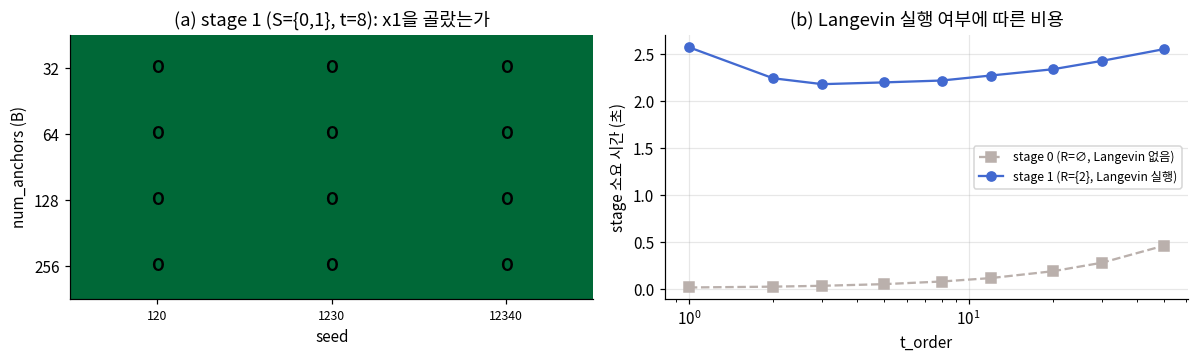

stage 1 성공 비율 (seed 3개):
  B=  32 : 1.00
  B=  64 : 1.00
  B= 128 : 1.00
  B= 256 : 1.00


In [6]:
# stage 1의 anchor 수 / seed 안정성 (t=8)
st = S1["stage1_seed_stability"]
Bs1 = sorted({r["B"] for r in st})
sd1 = sorted({r["seed"] for r in st})
g1 = np.zeros((len(Bs1), len(sd1)))
for r in st:
    g1[Bs1.index(r["B"]), sd1.index(r["seed"])] = 1.0 if r["correct"] else 0.0

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

ax = axes[0]
ax.imshow(g1, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(sd1))); ax.set_xticklabels(sd1, fontsize=8)
ax.set_yticks(range(len(Bs1))); ax.set_yticklabels(Bs1)
ax.set_xlabel("seed"); ax.set_ylabel("num_anchors (B)")
ax.set_title("(a) stage 1 (S={0,1}, t=8): x1을 골랐는가")
for i in range(len(Bs1)):
    for j in range(len(sd1)):
        ax.text(j, i, "O" if g1[i, j] else "X", ha="center", va="center",
                fontsize=11, fontweight="bold")
ax.grid(False)

# stage 0 vs stage 1 소요 시간 (Langevin 유무 차이)
ax = axes[1]
s0r = S1["stage0_reference"]
ax.plot([r["t_order"] for r in s0r], [r["wall_seconds"] for r in s0r],
        "s--", color="#bab0ac", label="stage 0 (R=∅, Langevin 없음)")
ax.plot(t1, [r["wall_seconds"] for r in s1c],
        "o-", color="#4269d0", label="stage 1 (R={2}, Langevin 실행)")
ax.set_xscale("log"); ax.set_xlabel("t_order"); ax.set_ylabel("stage 소요 시간 (초)")
ax.set_title("(b) Langevin 실행 여부에 따른 비용"); ax.legend(fontsize=8)

fig.tight_layout(); plt.show()

print("stage 1 성공 비율 (seed 3개):")
for i, b in enumerate(Bs1):
    print(f"  B={b:4d} : {g1[i].mean():.2f}")

## 7. 결과 ③: **off-diagonal $E|H_{i,i_*}|$ — leaf의 부모 찾기**

지금까지는 Hessian **대각** 성분의 *분산*으로 leaf $i_*$ 를 골랐습니다.
이제 같은 Hessian의 **off-diagonal** 성분을 봅니다. 선택된 leaf $i_*$ 에 대해

$$A_i \;=\; \mathbb{E}_{\text{anchors}}\big|\,H_{i,\,i_*}(x_S,t)\,\big|,
\qquad i \in S\setminus\{i_*\}$$

를 여러 $t$ 에 대해 그립니다. 대각 분산과 달리 **절댓값의 기대값**입니다.

> **해석 방향 (중요):** $H_{i,i_*}$ 는 $\partial^2 \log p_t/\partial x_i \partial x_{i_*}$ 로,
> 두 좌표 사이의 **의존성**을 재는 양입니다. 따라서
> **$A_i$ 가 클수록 $i$ 가 $i_*$ 의 부모일 가능성이 큽니다.**
> 반대로 $A_i \approx 0$ 이면 $i$ 는 $i_*$ 의 **부모가 아닙니다**.
> (선형 가우시안 사슬에서 $t\to0$ 일 때 비부모 항이 정확히 0으로 수렴함을
> `tests/test_offdiag_parent_signal.py` 에서 해석적으로 고정해 두었습니다.)

참값 (사슬 `0 -> 1 -> 2`):

| stage | $S$ | leaf $i_*$ | 참 부모 | 비부모 |
|---|---|---|---|---|
| **stage 0** | `{0,1,2}` | **x2** | **x1** | x0 |
| **stage 1** | `{0,1}` | **x1** | **x0** | (없음) |

stage 0이 판별력을 보는 핵심입니다: `x1`(참 부모)의 $A$ 가 `x0`(비부모)보다 커야 합니다.

In [7]:
with open("results/dag_ordering_summary/offdiag_summary.json") as f:
    OD = json.load(f)

print(OD["interpretation"])
print("참 부모 관계:", OD["true_parents"], "  (키=노드, 값=그 노드의 부모들)")

od0 = OD["stage0"]
od1 = OD["stage1"]

print(f"\n[stage 0] S={{0,1,2}}, 기대 leaf = x2")
print(f"{'t':>4} | {'leaf':>5} | {'E|H(x0,i*)| (비부모)':>22} | {'E|H(x1,i*)| (참 부모)':>22} | {'비율':>6}")
print("-" * 78)
for r in od0:
    S, k = r["S"], r["selected_local_index"]
    am = np.array(r["abs_mean"]); se = np.array(r["abs_se"])
    i_star = r["selected_leaf"]
    if i_star != 2:
        print(f"{r['t_order']:>4} | {'x%d' % i_star:>5} |"
              f" {'(leaf 선택 실패 — 비교 무의미)':>22}")
        continue
    j0, j1 = S.index(0), S.index(1)
    a0, a1 = am[j0, k], am[j1, k]
    print(f"{r['t_order']:>4} | {'x%d' % i_star:>5} |"
          f" {a0:12.4f} ± {se[j0, k]:6.4f} | {a1:12.4f} ± {se[j1, k]:6.4f} |"
          f" {a1 / a0:6.2f}" + ("" if a1 > a0 else "   <- 뒤집힘"))

A_i = E_anchors |H_{i,i*}|. LARGE => i is likely a parent of the selected leaf i*; near zero => likely NOT a parent.
참 부모 관계: {'0': [], '1': [0], '2': [1]}   (키=노드, 값=그 노드의 부모들)

[stage 0] S={0,1,2}, 기대 leaf = x2
   t |  leaf |      E|H(x0,i*)| (비부모) |     E|H(x1,i*)| (참 부모) |     비율
------------------------------------------------------------------------------
   1 |    x1 |  (leaf 선택 실패 — 비교 무의미)
   2 |    x0 |  (leaf 선택 실패 — 비교 무의미)
   3 |    x2 |       3.9942 ± 0.2679 |       4.7641 ± 0.3067 |   1.19
   5 |    x2 |       2.4016 ± 0.1521 |       3.1458 ± 0.2251 |   1.31
   8 |    x2 |       1.3919 ± 0.1012 |       2.4249 ± 0.1406 |   1.74
  12 |    x2 |       0.8347 ± 0.0622 |       1.8762 ± 0.0941 |   2.25
  20 |    x2 |       0.4532 ± 0.0360 |       1.3547 ± 0.0592 |   2.99
  30 |    x2 |       0.3047 ± 0.0259 |       0.9545 ± 0.0424 |   3.13
  50 |    x2 |       0.2050 ± 0.0166 |       0.4829 ± 0.0229 |   2.36


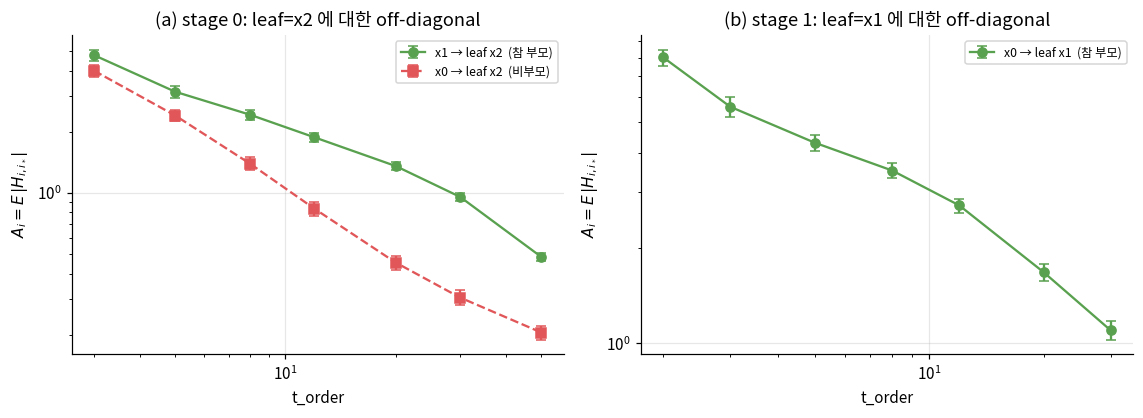

stage 0: leaf가 올바로 x2로 뽑힌 7개 t 중 7개에서 참 부모 x1의 A가 더 큼
  비율 범위: 1.19 ~ 3.13


In [8]:
# t별 off-diagonal 절댓값 기대값 (오차막대 = anchor 평균의 표준오차)
t_od = [r["t_order"] for r in od0]

def series(recs, node, leaf_expected):
    # (값, 표준오차) 배열; leaf 선택이 기대와 다른 t는 NaN 처리
    v, e = [], []
    for r in recs:
        S, k = r["S"], r["selected_local_index"]
        if r["selected_leaf"] != leaf_expected or node not in S or S.index(node) == k:
            v.append(np.nan); e.append(np.nan); continue
        j = S.index(node)
        v.append(np.array(r["abs_mean"])[j, k])
        e.append(np.array(r["abs_se"])[j, k])
    return np.array(v), np.array(e)

a0, e0 = series(od0, 0, 2)   # x0 -> leaf x2 : 비부모
a1, e1 = series(od0, 1, 2)   # x1 -> leaf x2 : 참 부모
b0, f0 = series(od1, 0, 1)   # x0 -> leaf x1 : 참 부모 (stage 1)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))

# (a) stage 0 절대값
ax = axes[0]
ax.errorbar(t_od, a1, yerr=e1, fmt="o-", color="#59a14f", capsize=3,
            label="x1 → leaf x2  (참 부모)")
ax.errorbar(t_od, a0, yerr=e0, fmt="s--", color="#e15759", capsize=3,
            label="x0 → leaf x2  (비부모)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("t_order"); ax.set_ylabel(r"$A_i=E\,|H_{i,i_*}|$")
ax.set_title("(a) stage 0: leaf=x2 에 대한 off-diagonal"); ax.legend(fontsize=8)

# (b) stage 1
ax = axes[1]
ax.errorbar(t_od, b0, yerr=f0, fmt="o-", color="#59a14f", capsize=3,
            label="x0 → leaf x1  (참 부모)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("t_order"); ax.set_ylabel(r"$A_i=E\,|H_{i,i_*}|$")
ax.set_title("(b) stage 1: leaf=x1 에 대한 off-diagonal"); ax.legend(fontsize=8)

fig.tight_layout(); plt.show()

ok = np.nansum(a1 > a0); tot = np.sum(~np.isnan(a1))
print(f"stage 0: leaf가 올바로 x2로 뽑힌 {tot}개 t 중 {int(ok)}개에서 "
      f"참 부모 x1의 A가 더 큼")
print(f"  비율 범위: {np.nanmin(a1 / a0):.2f} ~ {np.nanmax(a1 / a0):.2f}")

### 이 결과의 의미

- **참 부모 x1이 항상 더 큽니다.** leaf가 올바로 `x2` 로 뽑힌 모든 $t$(3~50)에서
  $A_{x_1} > A_{x_0}$ 이고, 오차막대(anchor 평균의 표준오차)를 훨씬 넘는 차이입니다.
  예를 들어 $t=20$ 에서 비부모 $0.453\pm0.036$ vs 참 부모 $1.355\pm0.059$.
  → **off-diagonal의 절댓값 기대값이 부모 후보를 실제로 골라냅니다.**
- **분리도는 $t$ 가 커질수록 커집니다** (비율 t=3에서 1.19배 → t=30에서 3.13배).
  절대값 자체는 둘 다 작아지지만, 비부모 쪽이 **더 빨리** 0으로 가기 때문입니다.
  즉 leaf 선택(대각 분산)과 부모 판별(off-diagonal)은 **선호하는 $t$ 가 다를 수 있습니다.**
- **주의:** 이 "$t$ 가 클수록 좋다"는 경향은 이 예제의 유한한 $t$ 범위에서 관찰된 것이고,
  선형 가우시안 해석해로 보면 $t\to0$ (즉 $\bar\alpha\to1$)에서 비부모 항이 정확히 0이 되어
  분리도가 **가장 큽니다**(테스트에서 112배). 여기서 작은 $t$ 의 비율이 낮게 나오는 것은
  이론적 한계가 아니라 5절에서 본 **$1/\sigma^4$ 추정 잡음** 때문입니다.
- stage 1은 후보가 `x0` 하나뿐이라 판별 문제가 아니지만, 참 부모의 크기가
  $t$ 에 따라 매끄럽게 감소하는 것을 확인할 수 있습니다.

> **한계:** 여기서는 "부모일 가능성이 큰 순서"를 매길 뿐 **임계값을 정하지 않았습니다.**
> 실제로 sparse한 부모 집합을 뽑으려면 $A_i$ 에 대한 컷오프(또는 검정)가 추가로 필요하고,
> 그건 이 노트북 범위 밖입니다. 즉 이 절은 여전히 **순서/부모 후보 진단**이지
> sparse DAG 추정이 아닙니다.

## 8. 결과 ④: **표준화(standardized) 관점 — 시점별 상대 비교**

지금까지의 plot은 **절대값**이라 $t$ 가 커질수록 모든 값이 함께 작아졌습니다
(5절 criterion은 $t=1$ 에서 231 → $t=50$ 에서 0.23으로 약 1000배 감소).
그래서 "어느 $t$ 에서 노드 간 **구분이 잘 되는가**"를 눈으로 비교하기 어려웠습니다.

여기서는 **각 시점 $t$ 마다 따로** 표준화합니다:

$$z_i(t)\;=\;\frac{V_i(t)-\mathrm{mean}_j V_j(t)}{\mathrm{sd}_j V_j(t)}
\qquad\text{(그 } t \text{ 의 노드들에 대해서만)}$$

off-diagonal도 같은 방식으로, **그 $t$ 의 node pair들에 대해서만** 표준화합니다.
이렇게 하면 스케일이 사라지고 **상대적 순위와 분리 폭**만 남습니다.

- 대각 criterion: $z$ 가 **가장 낮은** 노드가 leaf로 선택됩니다.
- off-diagonal: $z$ 가 **가장 높은** pair가 부모 후보입니다.

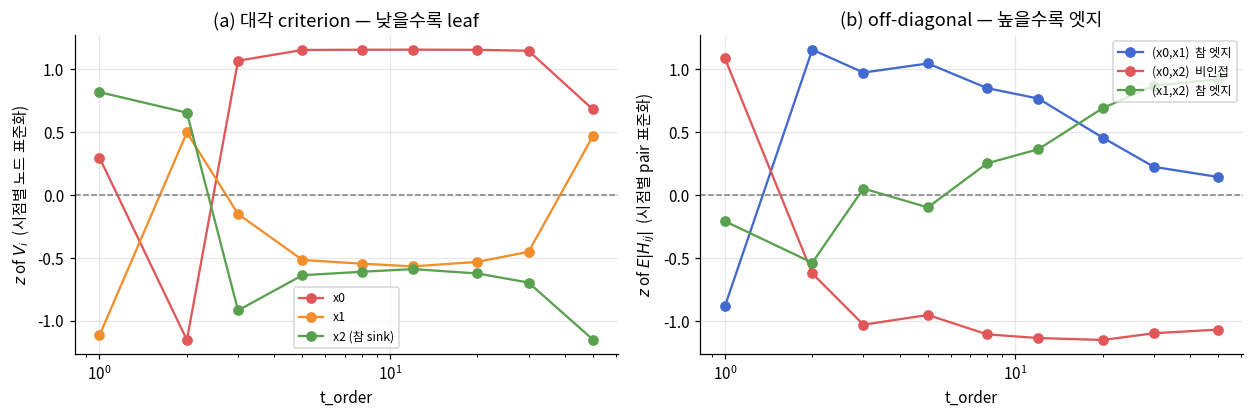

[대각 criterion z] (행=t, 열=x0,x1,x2)  — 가장 낮은 값이 leaf
   t       x0       x1       x2   선택
   1    0.298   -1.115    0.817   x1  (참 sink 아님)
   2   -1.151    0.497    0.654   x0  (참 sink 아님)
   3    1.067   -0.151   -0.916   x2
   5    1.153   -0.516   -0.637   x2
   8    1.154   -0.545   -0.609   x2
  12    1.155   -0.567   -0.588   x2
  20    1.153   -0.531   -0.623   x2
  30    1.146   -0.451   -0.695   x2
  50    0.680    0.469   -1.148   x2

[off-diagonal z] (행=t, 열=pair)  — 참 엣지=(x0,x1),(x1,x2) / 비인접=(x0,x2)
   t    (x0,x1)    (x0,x2)    (x1,x2)   최대
   1     -0.881      1.087     -0.205   (x0,x2)  <- 비인접(오답)
   2      1.154     -0.619     -0.534   (x0,x1)  <- 참 엣지
   3      0.972     -1.026      0.053   (x0,x1)  <- 참 엣지
   5      1.045     -0.949     -0.096   (x0,x1)  <- 참 엣지
   8      0.849     -1.102      0.253   (x0,x1)  <- 참 엣지
  12      0.766     -1.131      0.365   (x0,x1)  <- 참 엣지
  20      0.456     -1.147      0.690   (x1,x2)  <- 참 엣지
  30      0.225     -1.093      0.868

In [9]:
def zscore_rows(M):
    # 각 행(=시점)마다 독립적으로 z-score. 분모가 0에 가까우면 0으로 둠.
    M = np.asarray(M, dtype=float)
    mu = M.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, ddof=1, keepdims=True)
    sd = np.where(sd < 1e-12, np.nan, sd)
    return (M - mu) / sd

# --- (1) 대각 criterion V_i : 시점별로 3개 노드에 대해 표준화 ---
crit_z = zscore_rows(crit)          # crit: (T, 3), 5절에서 정의됨

# --- (2) off-diagonal E|H_ij| : 시점별로 node pair 3개에 대해 표준화 ---
pairs = [(0, 1), (0, 2), (1, 2)]
pair_abs = []
for r in ts:                         # ts = R["t_sweep"] (5절)
    tt = r["t_order"]
    rec = next((x for x in od0 if x["t_order"] == tt), None)
    am = np.array(rec["abs_mean"])
    S = rec["S"]
    pair_abs.append([am[S.index(i), S.index(j)] for i, j in pairs])
pair_abs = np.array(pair_abs)        # (T, 3 pairs)
pair_z = zscore_rows(pair_abs)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

ax = axes[0]
for k, c in zip(range(3), ["#e15759", "#f28e2b", "#59a14f"]):
    ax.plot(t_vals, crit_z[:, k], "o-", color=c,
            label=f"x{k}" + (" (참 sink)" if k == 2 else ""))
ax.axhline(0.0, color="gray", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("t_order")
ax.set_ylabel(r"$z$ of $V_i$  (시점별 노드 표준화)")
ax.set_title("(a) 대각 criterion — 낮을수록 leaf"); ax.legend(fontsize=8)

ax = axes[1]
colors = {"(0,1)": "#4269d0", "(0,2)": "#e15759", "(1,2)": "#59a14f"}
labels = {"(0,1)": "(x0,x1)  참 엣지", "(0,2)": "(x0,x2)  비인접",
          "(1,2)": "(x1,x2)  참 엣지"}
for k, (i, j) in enumerate(pairs):
    key = f"({i},{j})"
    ax.plot(t_vals, pair_z[:, k], "o-", color=colors[key], label=labels[key])
ax.axhline(0.0, color="gray", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("t_order")
ax.set_ylabel(r"$z$ of $E|H_{ij}|$  (시점별 pair 표준화)")
ax.set_title("(b) off-diagonal — 높을수록 엣지"); ax.legend(fontsize=8)

fig.tight_layout(); plt.show()

print("[대각 criterion z] (행=t, 열=x0,x1,x2)  — 가장 낮은 값이 leaf")
print(f"{'t':>4} " + " ".join(f"{'x%d' % k:>8}" for k in range(3)) + "   선택")
for i, tt in enumerate(t_vals):
    sel = int(np.argmin(crit_z[i]))
    print(f"{tt:>4} " + " ".join(f"{crit_z[i, k]:8.3f}" for k in range(3))
          + f"   x{sel}" + ("" if sel == 2 else "  (참 sink 아님)"))

print("\n[off-diagonal z] (행=t, 열=pair)  — 참 엣지=(x0,x1),(x1,x2) / 비인접=(x0,x2)")
print(f"{'t':>4} " + " ".join(f"{f'(x{i},x{j})':>10}" for i, j in pairs) + "   최대")
for i, tt in enumerate(t_vals):
    top = pairs[int(np.argmax(pair_z[i]))]
    print(f"{tt:>4} " + " ".join(f"{pair_z[i, k]:10.3f}" for k in range(3))
          + f"   (x{top[0]},x{top[1]})"
          + ("  <- 참 엣지" if top in [(0, 1), (1, 2)] else "  <- 비인접(오답)"))

### 표준화가 보여주는 것

- **(a) 대각 criterion:** $t\ge3$ 구간에서 `x2`(참 sink)의 $z$ 가 일관되게 가장 낮고,
  `x0`(source)는 $z\approx+1.15$ 로 거의 평평하게 유지됩니다.
  절대값 plot에서는 세 곡선이 모두 감소해 보였지만, 표준화하면 **상대적 분리가
  $t$ 에 걸쳐 안정적**이라는 사실이 드러납니다. 실패 구간($t=1,2$)에서만 순위가 흔들립니다.
- **(b) off-diagonal:** 사슬 `0->1->2` 의 **참 엣지는 `(x0,x1)` 과 `(x1,x2)` 두 개**이고,
  **비인접 pair는 `(x0,x2)` 하나**입니다. 표준화 결과, $t\ge2$ 의 모든 시점에서
  **비인접 `(x0,x2)` 가 항상 최하위**($z\approx-1.0\sim-1.15$)이고 두 참 엣지가 위에 있습니다.
  → **엣지/비엣지 구분은 잘 됩니다.**
- 다만 **두 참 엣지 사이의 순위는 $t$ 에 따라 바뀝니다**: 작은 $t$ 에서는 `(x0,x1)` 이,
  $t\ge20$ 에서는 `(x1,x2)` 가 높습니다. 이는 선형 가우시안 해석해에서도 동일하게 나타나는
  현상으로($\bar\alpha=0.9$ 에서 `(0,1)` 우세 → $\bar\alpha=0.7$ 부터 `(1,2)` 우세),
  **추정 오차가 아니라 대상 자체의 성질**입니다. 즉 $E|H_{ij}|$ 의 절대 순위로
  "어느 엣지가 더 강한가"를 읽으면 안 됩니다.
- 표준화는 **시점 간 비교**를 가능하게 해주지만, 각 $t$ 안에서의 순위는 바꾸지 않습니다
  (선형 변환이므로). 즉 leaf/부모 **선택 결과 자체는 동일**하고, 보기에만 도움을 줍니다.

## 9. 결과 ⑤: **v-structure `0 -> 2 <- 1` — ordering + parents end-to-end**

지금까지는 사슬 `0 -> 1 -> 2` 하나만 봤습니다. 구조가 다르면 어떻게 되는지
**v-structure(collider)** 로 전체 파이프라인을 처음부터 끝까지 돌렸습니다.

$$x_0=e_0,\qquad x_1=e_1,\qquad x_2=f(x_0)+g(x_1)+e_2$$

v-structure가 사슬보다 **구조적으로 까다로운 이유**:

| 성질 | 사슬 `0->1->2` | v-structure `0->2<-1` |
|---|---|---|
| 참 topological order | `[0,1,2]` **하나** | `[0,1,2]`, `[1,0,2]` **둘** (source가 교환 가능) |
| source끼리의 관계 | `x0 -> x1` (엣지 있음) | $x_0 \perp x_1$ **주변 독립** |
| sink의 부모 수 | 1개 (`x1`) | **2개** (`x0`, `x1`) |
| collider 효과 | 없음 | $x_2$ 를 조건부로 주면 $x_0,x_1$ 이 **의존** |

order가 **두 개**이므로 하나의 정답 순열과 비교하면 안 되고,
**order FNR**과 **stagewise leaf validity**로 평가해야 합니다 (7절 진단 모듈이 이미 그렇게 합니다).

부모 추정 관점에서는 sink `x2` 의 부모가 **둘**이므로,
$A_i=E|H_{i,x_2}|$ 가 `x0`, `x1` **양쪽 모두** 커야 하고,
stage 1에서 남은 두 source는 서로 부모가 아니므로 $E|H_{x_0,x_1}|$ 이 **작아야** 합니다.

In [10]:
with open("results/dag_ordering_summary/vstructure_summary.json") as f:
    V = json.load(f)

print("구조        :", V["structure"])
print("인접행렬    :\n", np.array(V["adjacency"]))
print("참 부모     :", V["true_parents"])
print("유효한 order:", V["valid_topological_orders"], " (source 교환 가능)")

Xv = np.load("data/dag_ordering_debug/dag3_vstructure.npy")
print(f"\nx0-x1 상관계수 = {np.corrcoef(Xv[:, 0], Xv[:, 1])[0, 1]:+.4f}  (주변 독립 -> 0에 가까움)")
print(f"x0-x2 상관계수 = {np.corrcoef(Xv[:, 0], Xv[:, 2])[0, 1]:+.4f}")
print(f"x1-x2 상관계수 = {np.corrcoef(Xv[:, 1], Xv[:, 2])[0, 1]:+.4f}")

print(f"\n[end-to-end ordering]  (anchor {V['num_anchors']}개)")
print(f"{'t':>4} | {'topological_order':>18} | {'FNR':>5} | {'첫 leaf':>7} | {'leaf validity':>13}")
print("-" * 68)
for r in V["ordering"]:
    ok = "OK" if r["order_is_valid"] else "X "
    print(f"{r['t_order']:>4} | {str(r['topological_order']):>18} | {r['order_fnr']:5.2f} |"
          f" {'x%d' % r['first_leaf']:>7} | {r['leaf_valid']:>6}/{r['leaf_stages']:<6} {ok}")

구조        : v-structure 0 -> 2 <- 1
인접행렬    :
 [[0 0 1]
 [0 0 1]
 [0 0 0]]
참 부모     : {'0': [], '1': [], '2': [0, 1]}
유효한 order: [[0, 1, 2], [1, 0, 2]]  (source 교환 가능)

x0-x1 상관계수 = -0.0080  (주변 독립 -> 0에 가까움)
x0-x2 상관계수 = +0.5570
x1-x2 상관계수 = +0.4311

[end-to-end ordering]  (anchor 256개)
   t |  topological_order |   FNR |  첫 leaf | leaf validity
--------------------------------------------------------------------
   1 |          [0, 2, 1] |  0.50 |      x1 |      2/3      X 
   2 |          [0, 2, 1] |  0.50 |      x1 |      2/3      X 
   3 |          [0, 1, 2] |  0.00 |      x2 |      3/3      OK
   5 |          [0, 2, 1] |  0.50 |      x1 |      2/3      X 
   8 |          [0, 1, 2] |  0.00 |      x2 |      3/3      OK
  12 |          [0, 1, 2] |  0.00 |      x2 |      3/3      OK
  20 |          [0, 1, 2] |  0.00 |      x2 |      3/3      OK
  30 |          [0, 1, 2] |  0.00 |      x2 |      3/3      OK
  50 |          [0, 1, 2] |  0.00 |      x2 |      3/3      OK


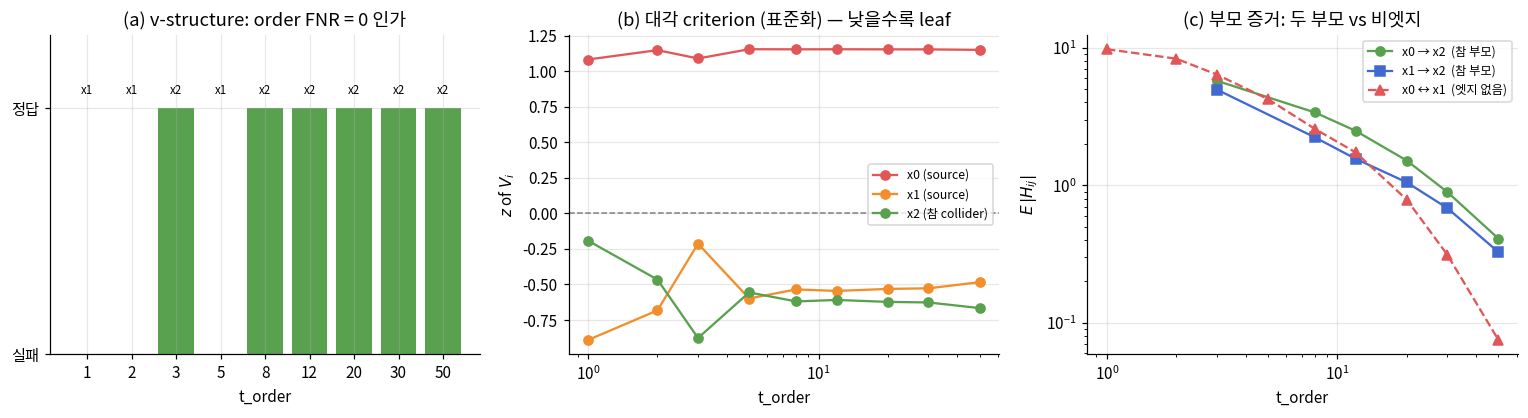

[stage 0] leaf=x2 로 맞은 t 에서 두 부모의 E|H|
   t  E|H(x0,x2)|  E|H(x1,x2)|   (둘 다 커야 정답)
   3       5.7411       4.9552
   8       3.3775       2.2258
  12       2.4845       1.5568
  20       1.5114       1.0494
  30       0.8934       0.6822
  50       0.4094       0.3267

[stage 1] 두 source 사이 E|H(x0,x1)| — 엣지가 없으므로 작아야 함
   t  E|H(x0,x1)|
   1       9.7325
   2       8.3078
   3       6.3688
   5       4.2225
   8       2.5632
  12       1.7328
  20       0.7858
  30       0.3126
  50       0.0751


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
tv = [r["t_order"] for r in V["ordering"]]

# (a) ordering 정확도
ax = axes[0]
okv = [r["order_is_valid"] for r in V["ordering"]]
ax.bar(range(len(tv)), [1 if o else 0 for o in okv],
       color=["#59a14f" if o else "#e15759" for o in okv])
ax.set_xticks(range(len(tv))); ax.set_xticklabels(tv)
ax.set_ylim(0, 1.3); ax.set_yticks([0, 1]); ax.set_yticklabels(["실패", "정답"])
ax.set_xlabel("t_order"); ax.set_title("(a) v-structure: order FNR = 0 인가")
for i, r in enumerate(V["ordering"]):
    ax.text(i, 1.06, f"x{r['first_leaf']}", ha="center", fontsize=7.5)

# (b) stage 0 대각 criterion (표준화) — x2가 최저여야 정답
ax = axes[1]
cz = zscore_rows(np.array([r["diag_variance"] for r in V["stage0"]]))
for k, c in zip(range(3), ["#e15759", "#f28e2b", "#59a14f"]):
    ax.plot(tv, cz[:, k], "o-", color=c,
            label=f"x{k}" + (" (참 collider)" if k == 2 else " (source)"))
ax.axhline(0.0, color="gray", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("t_order")
ax.set_ylabel(r"$z$ of $V_i$"); ax.set_title("(b) 대각 criterion (표준화) — 낮을수록 leaf")
ax.legend(fontsize=8)

# (c) 부모 증거: leaf가 x2로 맞은 t만
ax = axes[2]
pa0, pa1, tp = [], [], []
for r in V["stage0"]:
    if not r["leaf_correct"]:
        continue
    S, k = r["S"], r["selected_local_index"]
    am = np.array(r["abs_mean"])
    tp.append(r["t_order"])
    pa0.append(am[S.index(0), k]); pa1.append(am[S.index(1), k])
src = [r["offdiag_abs_mean_vs_leaf"] for r in V["stage1"]]
s01 = [list(d.values())[0] for d in src]

ax.plot(tp, pa0, "o-", color="#59a14f", label="x0 → x2  (참 부모)")
ax.plot(tp, pa1, "s-", color="#4269d0", label="x1 → x2  (참 부모)")
ax.plot(tv, s01, "^--", color="#e15759", label="x0 ↔ x1  (엣지 없음)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("t_order"); ax.set_ylabel(r"$E\,|H_{ij}|$")
ax.set_title("(c) 부모 증거: 두 부모 vs 비엣지"); ax.legend(fontsize=8)

fig.tight_layout(); plt.show()

print("[stage 0] leaf=x2 로 맞은 t 에서 두 부모의 E|H|")
print(f"{'t':>4} {'E|H(x0,x2)|':>12} {'E|H(x1,x2)|':>12}   (둘 다 커야 정답)")
for t_, v0, v1 in zip(tp, pa0, pa1):
    print(f"{t_:>4} {v0:12.4f} {v1:12.4f}")
print(f"\n[stage 1] 두 source 사이 E|H(x0,x1)| — 엣지가 없으므로 작아야 함")
print(f"{'t':>4} {'E|H(x0,x1)|':>12}")
for r in V["stage1"]:
    print(f"{r['t_order']:>4} {list(r['offdiag_abs_mean_vs_leaf'].values())[0]:12.4f}")

### v-structure 결과 해석

**① Ordering — 대체로 성공, 그러나 사슬보다 불안정**

9개 $t$ 중 **6개**($t=3,8,12,20,30,50$)에서 order FNR $=0$, leaf validity $3/3$ 으로
collider `x2` 를 첫 leaf로 정확히 뽑았습니다.
$t=1,2$ 실패는 사슬과 동일한 $1/\sigma^4$ 잡음이지만, **$t=5$ 에서도 실패**한 것은 사슬에 없던 현상입니다
(사슬은 $t\ge3$ 이후 전부 성공). v-structure가 더 어렵다는 증거로 볼 수 있습니다.

**② 부모 추정 — 두 부모를 모두 잡아냄**

- leaf가 `x2` 로 맞은 모든 $t$ 에서 $E|H_{x_0,x_2}|$ 와 $E|H_{x_1,x_2}|$ **둘 다 큽니다**.
  사슬에서 부모 1개를 골라내던 것과 달리, **부모가 2개인 경우도 양쪽 모두** 신호가 뜹니다.
- 결정적으로, **stage 1의 $E|H_{x_0,x_1}|$ 는 $t$ 가 커질수록 급격히 0으로 갑니다**
  ($t=8$ 에서 2.56 → $t=50$ 에서 **0.075**). 두 source 사이에는 엣지가 없기 때문입니다.
  같은 양이 사슬(`x0->x1` 엣지 존재)에서는 $t=50$ 에서도 0.5 수준이었습니다.
  → **엣지 유무를 실제로 구분합니다.**

**③ 그러나 주의할 점**

- 큰 $t$ 에서 $E|H_{x_0,x_1}|\to0$ 인 것은 **collider 구조와 잘 맞아떨어진 결과**이지만,
  6절에서 본 것처럼 큰 $t$ 에서는 Langevin marginal 근사도 함께 열화됩니다.
  두 효과가 같은 방향으로 보이므로, **"작아졌으니 엣지가 없다"고 단정하려면
  근사 품질을 따로 확인**해야 합니다.
- 여전히 **임계값이 없습니다.** "0.075는 작고 2.2는 크다"는 판단은 사람이 한 것이고,
  자동화하려면 컷오프나 검정이 필요합니다 (7절 말미의 한계와 동일).

## 10. 결과 ⑥: posterior 샘플 수(M)가 anchor 수보다 결정적

criterion은 "anchor들 간의 분산"이므로 anchor 수 $B$ 가 중요할 것 같지만,
실제로는 **anchor 하나당 posterior 샘플 수 $M$ = chains × retained** 가 더 결정적이었습니다.
$M$ 이 부족하면 공분산 추정 자체가 부정확해 $H_{ii}$ 가 통째로 흔들립니다.

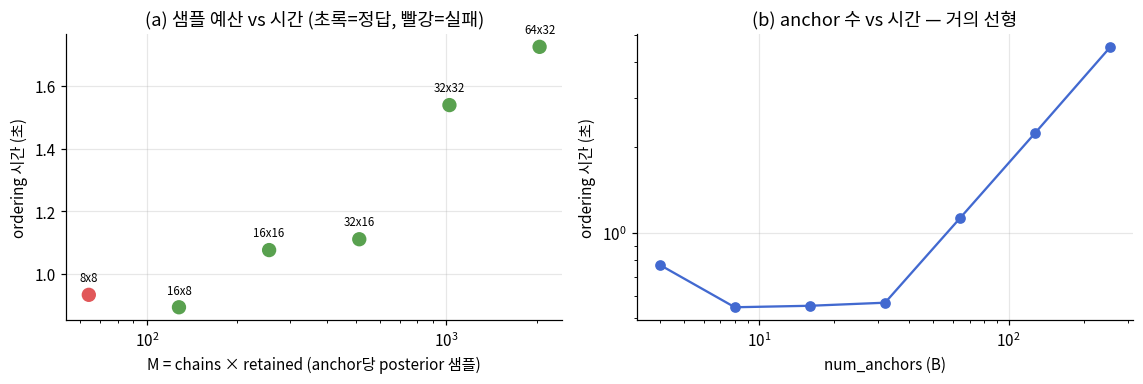

chains x retained =    M | 시간(s) | 순서
------------------------------------------------
     8 x 8        =   64 |   0.93 | [1, 2, 0] X (실패)
    16 x 8        =  128 |   0.89 | [0, 1, 2] OK
    16 x 16       =  256 |   1.08 | [0, 1, 2] OK
    32 x 16       =  512 |   1.11 | [0, 1, 2] OK
    32 x 32       = 1024 |   1.54 | [0, 1, 2] OK
    64 x 32       = 2048 |   1.72 | [0, 1, 2] OK


In [12]:
cs = R["cost_sweep"]
M = [r["posterior_samples_per_anchor"] for r in cs]
tt = [r["wall_seconds"] for r in cs]
okc = [r["correct"] for r in cs]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))

ax = axes[0]
ax.scatter(M, tt, c=["#59a14f" if o else "#e15759" for o in okc], s=70, zorder=3)
for r in cs:
    ax.annotate(f"{r['chains']}x{r['samples']}",
                (r["posterior_samples_per_anchor"], r["wall_seconds"]),
                textcoords="offset points", xytext=(0, 9), ha="center", fontsize=7.5)
ax.set_xscale("log"); ax.set_xlabel("M = chains × retained (anchor당 posterior 샘플)")
ax.set_ylabel("ordering 시간 (초)")
ax.set_title("(a) 샘플 예산 vs 시간 (초록=정답, 빨강=실패)")

ax = axes[1]
bs = [r["num_anchors"] for r in R["anchor_sweep"]]
bt = [r["wall_seconds"] for r in R["anchor_sweep"]]
ax.plot(bs, bt, "o-", color="#4269d0")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("num_anchors (B)"); ax.set_ylabel("ordering 시간 (초)")
ax.set_title("(b) anchor 수 vs 시간 — 거의 선형")
fig.tight_layout(); plt.show()

print("chains x retained =    M | 시간(s) | 순서")
print("-" * 48)
for r in cs:
    print(f"{r['chains']:>6} x {r['samples']:<8} = {r['posterior_samples_per_anchor']:>4} |"
          f" {r['wall_seconds']:6.2f} | {r['topological_order']}"
          f" {'OK' if r['correct'] else 'X (실패)'}")

**핵심:** $M=64$ 에서는 실패하고 $M\ge128$ 부터 정답입니다 (t=8, B=64 고정).
반면 anchor 수 $B$ 는 시간에 거의 **선형**으로 영향을 주므로,
예산이 한정될 때는 **$M$ 을 먼저 충분히 확보**하는 편이 낫습니다.

## 11. 결과 ⑦: 안정성 — 솔직한 한계

여기가 이 실험에서 **가장 조심해야 할 부분**입니다.
GPU에서 seed 5개를 바꿔 돌리면 t=8, B=128에서 전부 정답이 나옵니다.
하지만 **CPU에서 같은 seed로 돌리면 결과가 달라집니다.**

`torch.Generator` 는 CPU와 CUDA에서 **서로 다른 난수 스트림**을 생성합니다.
각 장치 내에서는 완전히 재현 가능하지만(동일 seed → 동일 결과), 장치 간에는 anchor와 Langevin 노이즈가 달라집니다.
$B$ 가 작을 때 노드 1과 2의 criterion 차이가 작아서(예: 5.80 vs 6.17) 이 차이만으로 순서가 뒤집힙니다.

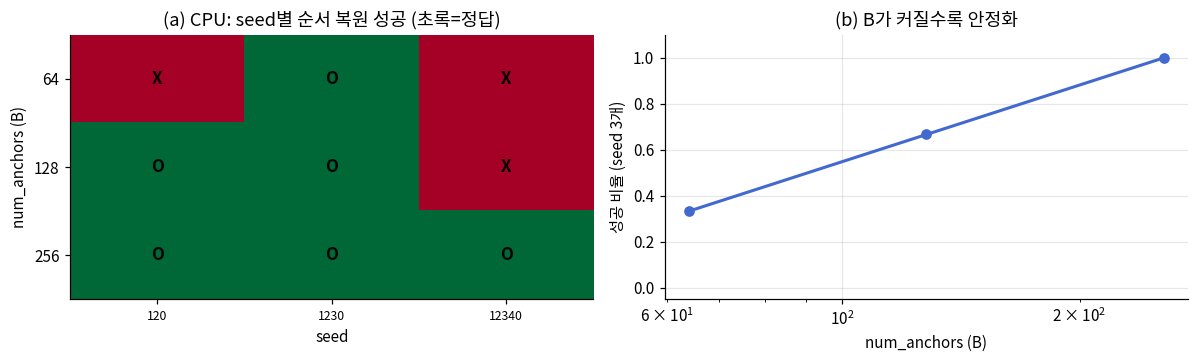

GPU seed 안정성 (t=8, B=128):
  seed=     120 -> [0, 1, 2]  FNR=0.00
  seed=    1230 -> [0, 1, 2]  FNR=0.00
  seed=   12340 -> [0, 1, 2]  FNR=0.00
  seed=  123450 -> [0, 1, 2]  FNR=0.00
  seed= 1234560 -> [0, 1, 2]  FNR=0.00

CPU vs GPU (동일 seed=120, t=8, B=64):
  cpu      -> [0, 2, 1]  (2.20s)
  cuda:0   -> [0, 1, 2]  (1.19s)


In [13]:
cpu = R["cpu_stability"]
Bs = sorted({r["B"] for r in cpu})
seeds = sorted({r["seed"] for r in cpu})
grid = np.zeros((len(Bs), len(seeds)))
for r in cpu:
    grid[Bs.index(r["B"]), seeds.index(r["seed"])] = 1.0 if r["correct"] else 0.0

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

ax = axes[0]
ax.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(seeds))); ax.set_xticklabels(seeds, fontsize=8)
ax.set_yticks(range(len(Bs))); ax.set_yticklabels(Bs)
ax.set_xlabel("seed"); ax.set_ylabel("num_anchors (B)")
ax.set_title("(a) CPU: seed별 순서 복원 성공 (초록=정답)")
for i in range(len(Bs)):
    for j in range(len(seeds)):
        ax.text(j, i, "O" if grid[i, j] else "X", ha="center", va="center",
                fontsize=11, fontweight="bold")
ax.grid(False)

ax = axes[1]
succ = grid.mean(axis=1)
ax.plot(Bs, succ, "o-", color="#4269d0", lw=2)
ax.set_xscale("log"); ax.set_ylim(-0.05, 1.1)
ax.set_xlabel("num_anchors (B)"); ax.set_ylabel("성공 비율 (seed 3개)")
ax.set_title("(b) B가 커질수록 안정화")
fig.tight_layout(); plt.show()

print("GPU seed 안정성 (t=8, B=128):")
for r in R["seed_sweep"]:
    print(f"  seed={r['seed']:>8} -> {r['topological_order']}  FNR={r['order_fnr']:.2f}")
print("\nCPU vs GPU (동일 seed=120, t=8, B=64):")
for r in R["device_compare"]:
    print(f"  {r['device']:<8} -> {r['order']}  ({r['ordering_seconds']:.2f}s)")

### 이 결과가 말해주는 것

- 장치 내 **재현성은 완벽**합니다 (같은 seed, 같은 장치 → 항상 같은 결과).
- 그러나 **B=64, 128에서는 seed에 따라 결과가 뒤집힙니다.** B=256에서야 3개 seed 모두 정답이 됩니다.
- 따라서 **"t>=3이면 항상 정답"이라고 말할 수 없습니다.** 정확히는
  *"충분한 B와 M이 확보된 상태에서 t>=3이면 정답"* 입니다.
- **실무 권고:** 단일 실행 결과를 믿지 말고 **seed를 여러 개 돌려 순서가 일치하는지 확인**하세요.
  일치하지 않으면 B와 M을 늘려야 한다는 신호입니다.

## 12. 실행 시간 및 메모리 비교

비용 구조는 중첩적입니다:

```
(D-1) stages × B anchors × (chains × retained) × reverse draws × t_order 역확산 스텝
```

network 평가 횟수는 대략 $O(D\cdot B\cdot C\cdot M\cdot L\cdot t_{order})$ 에
Langevin 몫 $O(D\cdot B\cdot C\cdot(\text{burn-in}+M\cdot\text{thinning}))$ 가 더해집니다.

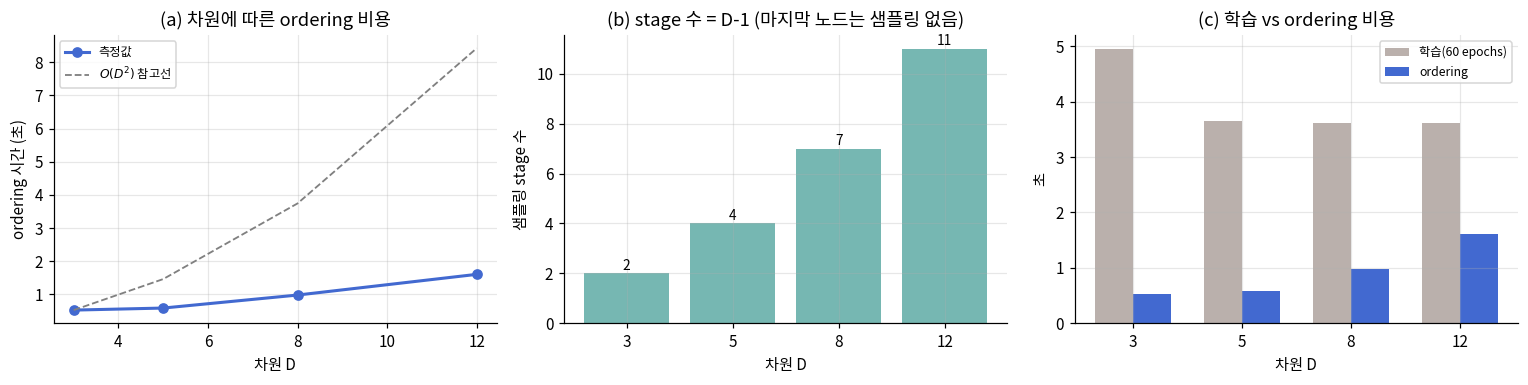

  D | stages |    학습(s) | ordering(s) | stage별(s)
------------------------------------------------------------------------
  3 |      2 |      5.0 |        0.53 | 0.27, 0.17
  5 |      4 |      3.7 |        0.59 | 0.02, 0.17, 0.23, 0.16
  8 |      7 |      3.6 |        0.98 | 0.02, 0.17, 0.16, 0.16, 0.16, 0.15, 0.16
 12 |     11 |      3.6 |        1.60 | 0.02, 0.17, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16


In [14]:
ds = R["d_scaling"]
Ds = [r["D"] for r in ds]
ord_s = [r["ordering_seconds"] for r in ds]
stages = [r["num_stages"] for r in ds]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

ax = axes[0]
ax.plot(Ds, ord_s, "o-", color="#4269d0", lw=2, label="측정값")
q = ord_s[0] / (Ds[0] ** 2)
ax.plot(Ds, [q * d ** 2 for d in Ds], "--", color="gray", lw=1.2, label=r"$O(D^2)$ 참고선")
ax.set_xlabel("차원 D"); ax.set_ylabel("ordering 시간 (초)")
ax.set_title("(a) 차원에 따른 ordering 비용"); ax.legend(fontsize=8)

ax = axes[1]
ax.bar([str(d) for d in Ds], stages, color="#76b7b2")
ax.set_xlabel("차원 D"); ax.set_ylabel("샘플링 stage 수")
ax.set_title("(b) stage 수 = D-1 (마지막 노드는 샘플링 없음)")
for i, s in enumerate(stages):
    ax.text(i, s + 0.15, str(s), ha="center", fontsize=9)

ax = axes[2]
w = 0.35
tr = [r["train_seconds"] for r in ds]
xs = np.arange(len(Ds))
ax.bar(xs - w/2, tr, w, label="학습(60 epochs)", color="#bab0ac")
ax.bar(xs + w/2, ord_s, w, label="ordering", color="#4269d0")
ax.set_xticks(xs); ax.set_xticklabels([str(d) for d in Ds])
ax.set_xlabel("차원 D"); ax.set_ylabel("초")
ax.set_title("(c) 학습 vs ordering 비용"); ax.legend(fontsize=8)

fig.tight_layout(); plt.show()

print(f"{'D':>3} | {'stages':>6} | {'학습(s)':>8} | {'ordering(s)':>11} | {'stage별(s)'}")
print("-" * 72)
for r in ds:
    ss = ", ".join(f"{x:.2f}" for x in r["stage_seconds"])
    print(f"{r['D']:>3} | {r['num_stages']:>6} | {r['train_seconds']:>8.1f} | "
          f"{r['ordering_seconds']:>11.2f} | {ss}")

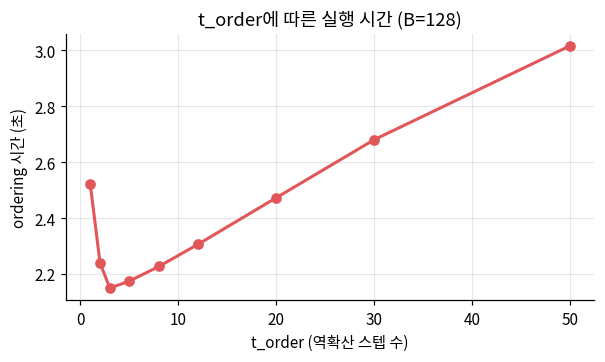

최대 CUDA 메모리: 0.0317 GB  (D=3, B=128 기준 — 매우 작음)
CPU 2.20s vs GPU 1.19s → 약 1.9배 (D=3에서는 GPU 이점이 작음; D와 M이 클수록 벌어짐)


In [15]:
# t_order는 역확산 스텝 수를 직접 늘리므로 시간에 선형으로 기여합니다.
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(t_vals, [r["wall_seconds"] for r in ts], "o-", color="#e15759", lw=2)
ax.set_xlabel("t_order (역확산 스텝 수)"); ax.set_ylabel("ordering 시간 (초)")
ax.set_title("t_order에 따른 실행 시간 (B=128)")
fig.tight_layout(); plt.show()

peak = [r["peak_cuda_bytes"] for r in ts if r["peak_cuda_bytes"]]
if peak:
    print(f"최대 CUDA 메모리: {max(peak)/1e9:.4f} GB  (D=3, B=128 기준 — 매우 작음)")

dc = {r["device"]: r["ordering_seconds"] for r in R["device_compare"]}
if "cpu" in dc and "cuda:0" in dc:
    print(f"CPU {dc['cpu']:.2f}s vs GPU {dc['cuda:0']:.2f}s "
          f"→ 약 {dc['cpu']/dc['cuda:0']:.1f}배 (D=3에서는 GPU 이점이 작음; D와 M이 클수록 벌어짐)")

### 실행 시간 요약 (실측)

| 항목 | 설정 | 시간 |
|---|---|---|
| 디버그 전체 실행 (CPU) | D=3, 30 epochs, B=4 | **3.2 초** (학습 2.5s + ordering 0.02s) |
| 실제 실행 (GPU) | D=3, 1500 epochs, B=64 | **126 초** (학습 123s + ordering 2.6s) |
| ordering만 (GPU) | t=8, B=128, M=512 | **2.3 초** |
| ordering만 (GPU) | t=8, B=256, M=512 | **4.5 초** |
| 최대 CUDA 메모리 | D=3, B=128 | **0.032 GB** |

**관찰:** 이 규모(D=3)에서는 **학습이 전체 시간의 98%** 를 차지하고 ordering은 무시할 수준입니다.
그러나 ordering 비용은 D, B, M, t_order 모두에 곱셈적으로 늘어나므로,
고차원에서는 역전됩니다 (stage 수가 D-1로 늘고 각 stage마다 전체 샘플링이 반복되므로 대략 $O(D^2)$).

## 13. 재현 방법

In [16]:
print(r'''
# 0) 환경
conda activate env_gpu

# 1) 테스트 (49개)
pytest -q                 # 49 passed
pytest -q -m slow         # 1 passed (CLI 왕복 테스트)

# 2) 디버그 데이터 생성 + CPU 디버그 실행 (수 분, 코드 검증용)
python data/make_dag_ordering_debug_data.py --output-dir data/dag_ordering_debug
python experiments/run_dag_ordering.py --config configs/dag_ordering_debug.json

# 3) 본 노트북의 "정답" 설정 (GPU)
python experiments/run_dag_ordering.py \
    --data-path data/dag_ordering_debug/dag3_chain.npy \
    --ground-truth-adjacency data/dag_ordering_debug/dag3_chain_adjacency.npy \
    --checkpoint-path results/dag_ordering/real_t3/ddpm.pt --train-if-missing \
    --output-dir results/dag_ordering/real_t8 \
    --epochs 1500 --timesteps 500 --mid-features 128 --num-temporal-layers 3 \
    --t-order 8 --num-anchors 256 --anchor-chunk-size 32 \
    --num-chains 32 --langevin-burn-in 300 --langevin-samples 16 \
    --langevin-thinning 10 --langevin-step-size 1e-3 --langevin-init forward_data \
    --reverse-draws-per-xt 1 --sampling-chunk-size 8192 \
    --seed 120 --device cuda:0 --max-memory-gb 16
''')


# 0) 환경
conda activate env_gpu

# 1) 테스트 (49개)
pytest -q                 # 49 passed
pytest -q -m slow         # 1 passed (CLI 왕복 테스트)

# 2) 디버그 데이터 생성 + CPU 디버그 실행 (수 분, 코드 검증용)
python data/make_dag_ordering_debug_data.py --output-dir data/dag_ordering_debug
python experiments/run_dag_ordering.py --config configs/dag_ordering_debug.json

# 3) 본 노트북의 "정답" 설정 (GPU)
python experiments/run_dag_ordering.py \
    --data-path data/dag_ordering_debug/dag3_chain.npy \
    --ground-truth-adjacency data/dag_ordering_debug/dag3_chain_adjacency.npy \
    --checkpoint-path results/dag_ordering/real_t3/ddpm.pt --train-if-missing \
    --output-dir results/dag_ordering/real_t8 \
    --epochs 1500 --timesteps 500 --mid-features 128 --num-temporal-layers 3 \
    --t-order 8 --num-anchors 256 --anchor-chunk-size 32 \
    --num-chains 32 --langevin-burn-in 300 --langevin-samples 16 \
    --langevin-thinning 10 --langevin-step-size 1e-3 --langevin-init forward_data \
    --reverse-draws-per-xt 1 --sampli

### 출력 파일

```text
results/dag_ordering/<run>/
├── config.json                 # 해석된 전체 설정
├── ordering_result.json        # leaf_order, topological_order, criterion_by_stage, warnings
├── stage_diagnostics.pt        # stage별 Hessian 대각, criterion, Langevin 진단
├── runtime.json                # 시간 + 최대 CUDA 메모리
└── checkpoint_reference.json   # 어떤 모델이 이 순서를 만들었는지
```

In [17]:
# 실제 실행 결과 확인 (디버그 실행 산출물)
p = "results/dag_ordering/debug/ordering_result.json"
if os.path.exists(p):
    d = json.load(open(p))
    print("leaf_order        :", d["leaf_order"])
    print("topological_order :", d["topological_order"], " (정답 [0,1,2])")
    print("t_order           :", d["t_order"])
    print("\ncriterion_by_stage:")
    for i, s in enumerate(d["criterion_by_stage"]):
        print(f"  stage {i}: " + ", ".join(f"x{k}={v:.2f}" for k, v in s.items()))
    print("\nwarnings:")
    for w in d["warnings"]:
        print("  -", w)
    print("\n주의: 디버그 설정은 anchor 4개 / 학습 30 epochs 로 의도적으로 최소화한 값이라")
    print("      순서가 틀립니다(FNR 0.5). 코드 경로 검증용이지 과학적 설정이 아닙니다.")
else:
    print("디버그 실행 산출물이 없습니다. 위 13절의 명령으로 먼저 실행하세요.")

leaf_order        : [1, 2, 0]
topological_order : [0, 2, 1]  (정답 [0,1,2])
t_order           : 3

criterion_by_stage:
  stage 0: x0=978.15, x1=142.26, x2=184.20
  stage 1: x0=446.99, x2=81.11

warnings:
  - Leaf criterion is evaluated at t_order > 0 on the NOISED density; the SCORE t=0 guarantee does not automatically transfer to positive diffusion times.

주의: 디버그 설정은 anchor 4개 / 학습 30 epochs 로 의도적으로 최소화한 값이라
      순서가 틀립니다(FNR 0.5). 코드 경로 검증용이지 과학적 설정이 아닙니다.


## 14. 검증 현황

### 테스트 57개 통과 (`pytest -q`)

| 테스트 파일 | 검증 내용 |
|---|---|
| `test_ddpm_score_adapter.py` (12) | mock 네트워크 대비 `score = -eps/sqrt(1-ᾱ)` **정확 일치**, 스칼라/배치 timestep, 범위·형상 오류 |
| `test_conditional_langevin_gaussian.py` (7) | 해석적 Gaussian 조건부 평균/공분산과 비교, **조건 좌표 불변성 bit-exact 확인**, R=∅ 스킵 |
| `test_tweedie_hessian_gaussian.py` (15) | $H=-[\bar\alpha\Sigma_0+(1-\bar\alpha)I]^{-1}$ 재현, **`sigma2**4`·`ᾱ` 누락 시 실패함을 명시 검증**, Welford=배치 일치 |
| `test_dag_ordering_smoke.py` (15) | 순열 검증, stage당 정확히 1개 제거, NaN/Inf 없음, 출력 파일 생성 |
| `test_offdiag_parent_signal.py` (8) | 7절의 부모 판별 근거: 선형 가우시안 사슬에서 참 부모의 $\|H_{i,i_*}\|$ 가 비부모보다 큼, $t\to0$ 에서 비부모 항이 0으로 수렴, 잡음이 커지면 분리도 감소 |

### 기존 코드 무결성

- `python -m compileall models experiments tests` → exit 0
- `DDPMEstimator().fit_predict()` **기능 확인** (import만이 아니라 실제 실행): 대칭 (4,4) 그래프 반환
- diff: **3503 insertions, 0 deletions** — 기존 파일은 `.gitignore`/`README.md` 추가 외 변경 없음

## 15. 결론과 남은 한계

### 확인된 것

1. 파이프라인이 **end-to-end로 동작**하며, 조건부 Langevin + 역확산 + Tweedie Hessian 경로가
   해석적 정답과 일치함을 테스트로 검증했습니다.
2. 잘 학습된 모델 + 충분한 예산(t=8, B=256, M>=128)에서 D=3 체인의
   **순서를 정확히 복원**했습니다 (order FNR 0.00, leaf validity 3/3).
3. **정량적 trade-off를 확인**했습니다: t가 작을수록 이론(t=0)에 가깝지만
   $1/\sigma_t^4$ 증폭 때문에 수치적으로 불안정해집니다.
4. **off-diagonal $E|H_{i,i_*}|$ 로 leaf의 부모를 식별**했습니다 (7절).
   leaf가 올바로 뽑힌 모든 $t$ 에서 참 부모 x1이 비부모 x0보다 큰 값을 가졌고,
   차이는 표준오차를 크게 상회했습니다.
5. **v-structure에서도 end-to-end로 동작**했습니다 (9절). collider `x2` 를 첫 leaf로
   정확히 뽑았고(9개 $t$ 중 6개에서 FNR 0), **부모 2개를 모두** 검출했으며,
   엣지가 없는 두 source 사이 $E|H|$ 는 $t=50$ 에서 0.075까지 떨어졌습니다.
6. **conditional sampling이 실제로 작동함을 확인**했습니다 (6절). $R=\{2\}$ 가 비어있지 않은
   stage 1에서, Langevin으로 $x_{t,2}$ 를 적분해 얻은 기준이 **2차원 재학습 oracle과 유사한 거동**을
   보이며 중간 t 구간에서 정답 leaf를 선택했습니다.

### 남은 한계 (과장 없이)

- **D=3 구조 두 개**(사슬, v-structure)뿐입니다. 방법론의 일반적 검증이 아니며,
  고차원·조밀한 그래프에서는 미검증입니다. v-structure는 사슬보다 불안정했습니다($t=5$ 추가 실패).
- **부모 추정에 임계값이 없습니다.** $E|H_{ij}|$ 로 순위만 매길 뿐,
  "얼마나 작아야 엣지가 없는가"를 자동으로 정하지 못합니다. sparse 구조 추정이 아닌 이유입니다.
- **작은 B에서 seed에 따라 결과가 뒤집힙니다** (11절). 단일 실행을 신뢰하면 안 됩니다.
  (단, 이는 stage 0에 국한된 현상이고 stage 1은 B=32에서도 안정적이었습니다.)
- **양쪽에서 실패 모드가 존재합니다.** stage 0은 *작은* t에서($1/\sigma^4$ 증폭),
  stage 1은 *큰* t에서(ULA marginal 근사 열화, oracle 대비 상대오차 t=30에서 208%) 무너집니다.
  실질적 동작 구간은 **두 실패가 겹치지 않는 중간 t(이 예제에서 대략 3~20)** 뿐이며,
  이 구간이 데이터마다 어디인지는 **미리 알 수 없습니다.**
- **양의 시점 기준은 실험적**이며 t=0 SCORE 보장이 자동으로 따라오지 않습니다.
- ULA는 **Metropolis 보정이 없어** $O(h)$ 편향이 남아 있습니다 (MALA는 full-joint log-density가
  필요해 score network만으로는 깔끔히 추가하기 어렵습니다).
- 비용이 중첩적이라 고차원 확장 시 계산량이 빠르게 증가합니다.
- 저장소의 `.npy`/`.pickle` 데이터는 **git-lfs 포인터**라 `git-lfs` 설치 전에는 사용할 수 없습니다.

### 실무 권고

> `t_order` 를 스윕하고, **seed를 여러 개** 돌려 순서가 일치하는지 확인하십시오.
> 불일치하면 `--num-anchors` 와 `--num-chains × --langevin-samples` 를 늘려야 한다는 신호입니다.
>
> 큰 `t_order` 에서 결과가 흔들린다면 **Langevin 쪽을 의심**하십시오
> (`--langevin-burn-in`, `--langevin-thinning` 증가 또는 `--langevin-step-size` 조정).
> 6절의 oracle 비교를 자기 데이터에 대해 재현해 보면 marginal 근사 품질을 직접 진단할 수 있습니다.